## Introduction
This notebook trains several machine learning models to predict close price from a property's physical and geographic features and evaluates their performance on the validation set.

In [1]:
import numpy as np
import pandas as pd

In [2]:
train = pd.read_csv('clean-data/sold_train.csv')
val = pd.read_csv('clean-data/sold_validation.csv')
test = pd.read_csv('clean-data/sold_test.csv')

## Part 1: Setup
#### 1.1 Load machine learning libraries and preprocessing pipeline

In [3]:
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder
from category_encoders import TargetEncoder
from utilities import impute_groupwise, get_preprocessor

In [4]:
from sklearn import set_config
import warnings

# suppress warnings from taking the mean of empty arrays
warnings.filterwarnings(action='ignore', message='Mean of empty slice')
# force every transformer to output clean pandas dataframes instead of raw numpy arrays
set_config(transform_output='pandas')

#### 1.2 Initiate performance tracker
Create a class to compute, log, and manage evaluation metrics across multiple machine learning models.

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

In [6]:
class ModelPerformanceTracker:
    # set tracker schema
    def __init__(self):
        self.summary = pd.DataFrame(columns=[
            'Model', 'Feature Size', 'R2', 'RMSE ($)', 'MAE ($)', 'MAPE (%)', 'MdAPE (%)'
        ])

    # calculate evaluation metrics and append them to the summary table
    def log_results(self, model_name, feature_size, y_true, y_pred):
        r2 = r2_score(y_true, y_pred)
        mae = mean_absolute_error(y_true, y_pred)
        rmse = root_mean_squared_error(y_true, y_pred)

        eps = 1e-8 # have an epsilon in place to prevent division by 0
        percentage_errors = np.abs((y_true - y_pred) / (y_true + eps)) * 100
        mape = np.mean(percentage_errors)
        mdape = np.median(percentage_errors)
        
        model_results = pd.DataFrame([{
            'Model': model_name,
            'Feature Size': feature_size,
            'R2': round(r2, 4),
            'RMSE ($)': round(rmse, 2),
            'MAE ($)': round(mae, 2), 
            'MAPE (%)': round(mape, 2),
            'MdAPE (%)': round(mdape, 2)
        }])
        if not model_results.empty:
            self.summary = pd.concat([self.summary, model_results], ignore_index=True)

    # return model performance summary sorted by MdAPE  
    def get_summary(self):
        return self.summary.sort_values(by='MdAPE (%)', ascending=True).reset_index(drop=True)

In [ ]:
# initiate the tracker
val_tracker = ModelPerformanceTracker()

## Part 2: Modeling and Tuning
Train different machine learning models with a predefined feature set.

In [8]:
location_cols = ['MLSAreaMajor', 'CountyOrParish', 'City', 'PostalCode', 'DistrictNa']
bool_cols = ['ViewYN', 'PoolPrivateYN', 'AttachedGarageYN', 'FireplaceYN'] # removed NewConstructionYN because property age is informative enough
numeric_cols = ['LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'Stories',
                'LotSizeSquareFeet', 'ParkingTotal', 'property_age']
X = location_cols + bool_cols + numeric_cols

In [9]:
X_train = train[X]
y_train = train['ClosePrice']

X_val = val[X]
y_val = val['ClosePrice']

X_test = test[X]
y_test = test['ClosePrice']

#### 2.1 Regression Models
Build linear regression models with a log-transformed target, beginning with ordinary least squares (OLS) and then extending to ridge regression and splines.

In [10]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import SplineTransformer

In [11]:
linear_preprocessor = get_preprocessor(
    location_cols, 
    bool_cols, 
    numeric_cols,
    scale_skewed=True
)

##### OLS

In [ ]:
ols_pipeline = Pipeline([
    ('features', linear_preprocessor),
    ('estimator', LinearRegression())
])

ols_model = TransformedTargetRegressor(
    regressor=ols_pipeline, func=np.log1p, inverse_func=np.expm1
)

ols_model.fit(X_train, y_train)
ols_pred_val = ols_model.predict(X_val)
val_tracker.log_results(
    model_name='Linear Regression', 
    feature_size=len(X),
    y_true=y_val, 
    y_pred=ols_pred_val
)

/var/folders/t2/p9112v_n469068__fty8_3nc0000gn/T/ipykernel_37709/1668477167.py:29: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.summary = pd.concat([self.summary, model_results], ignore_index=True)


In [ ]:
val_tracker.get_summary()

,Model,Feature Size,R2,RMSE ($),MAE ($),MAPE (%),MdAPE (%)
0,Linear Regression,16,0.8049,411236.98,215889.98,16.33,12.29


##### Ridge Regression

In [ ]:
ridge_pipeline = Pipeline([
    ('features', linear_preprocessor),
    ('estimator', Ridge(alpha=1.0)) # L2 penalty
])

ridge_model = TransformedTargetRegressor(
    regressor=ridge_pipeline, func=np.log1p, inverse_func=np.expm1
)

ridge_model.fit(X_train, y_train)
ridge_pred_val = ridge_model.predict(X_val)
val_tracker.log_results(
    model_name='Ridge Regression',
    feature_size=len(X),
    y_true=y_val,
    y_pred=ridge_pred_val
)

In [ ]:
val_tracker.get_summary()

,Model,Feature Size,R2,RMSE ($),MAE ($),MAPE (%),MdAPE (%)
0,Linear Regression,16,0.8049,411236.98,215889.98,16.33,12.29
1,Ridge Regression,16,0.8049,411238.83,215890.46,16.33,12.29


##### Non-Linear Regression

Given that regularization does not significantly improve the performance of linear regression models, try natural splines to introduce non-linearity.

In [16]:
n_knots = 5
degree = 3 # natural splines use cubic polynomials

In [17]:
spline_transformer = ColumnTransformer(
    transformers=[
        ('splines', 
         SplineTransformer(
             n_knots=n_knots, 
             degree=degree, 
             extrapolation='linear', # enforce linear boundaries
             include_bias=False),    # exclude intercept to reduce multi-collinearity
         make_column_selector(dtype_include=['float64', 'float32', 'int64', 'int32']))
    ],
    remainder='passthrough' 
)

spline_pipeline = Pipeline([
    ('features', linear_preprocessor),
    ('natural_splines', spline_transformer),
    ('estimator', LinearRegression())  
])

spline_model = TransformedTargetRegressor(
    regressor=spline_pipeline, func=np.log1p, inverse_func=np.expm1
)

In [ ]:
spline_model.fit(X_train, y_train)
spline_pred_val = spline_model.predict(X_val)

val_tracker.log_results(
    model_name=f'Natural Spline ({n_knots} Knots)',
    feature_size=len(X),
    y_true=y_val,
    y_pred=spline_pred_val
)

In [ ]:
val_tracker.get_summary()

,Model,Feature Size,R2,RMSE ($),MAE ($),MAPE (%),MdAPE (%)
0,Natural Spline (5 Knots),16,0.8383,374450.81,201161.63,15.19,11.22
1,Linear Regression,16,0.8049,411236.98,215889.98,16.33,12.29
2,Ridge Regression,16,0.8049,411238.83,215890.46,16.33,12.29


In [20]:
n_knots = 8

In [21]:
spline_transformer = ColumnTransformer(
    transformers=[
        ('splines', 
         SplineTransformer(
             n_knots=n_knots, 
             degree=degree, 
             extrapolation='linear', # enforce linear boundaries
             include_bias=False),    # exclude intercept to reduce multi-collinearity
         make_column_selector(dtype_include=['float64', 'float32', 'int64', 'int32']))
    ],
    remainder='passthrough' 
)

spline_pipeline = Pipeline([
    ('features', linear_preprocessor),
    ('natural_splines', spline_transformer),
    ('estimator', LinearRegression())  
])

spline_model = TransformedTargetRegressor(
    regressor=spline_pipeline, func=np.log1p, inverse_func=np.expm1
)

In [ ]:
spline_model.fit(X_train, y_train)
spline_pred_val = spline_model.predict(X_val)

val_tracker.log_results(
    model_name=f'Natural Spline ({n_knots} Knots)',
    feature_size=len(X),
    y_true=y_val,
    y_pred=spline_pred_val
)

In [ ]:
# increasing the number of knots provides only marginal improvement in MdAPE, suggesting more advanced models are needed
val_tracker.get_summary()

,Model,Feature Size,R2,RMSE ($),MAE ($),MAPE (%),MdAPE (%)
0,Natural Spline (8 Knots),16,0.8393,373194.96,200206.77,15.06,11.09
1,Natural Spline (5 Knots),16,0.8383,374450.81,201161.63,15.19,11.22
2,Linear Regression,16,0.8049,411236.98,215889.98,16.33,12.29
3,Ridge Regression,16,0.8049,411238.83,215890.46,16.33,12.29


#### 2.2 Tree-Based Models
Build tree-based models with a log-transformed target, beginning with decision tree and then extending to random forest and gradient boosting.

In [24]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [25]:
tree_preprocessor = get_preprocessor(
    location_cols, 
    bool_cols, 
    numeric_cols,
    scale_skewed=False # no need to normalize numeric features for tree architectures
)

##### Decision Trees

In [26]:
depth = 12

In [ ]:
dt_pipeline = Pipeline([
    ('features', tree_preprocessor),
    ('estimator', DecisionTreeRegressor(max_depth=depth, random_state=42))
])

dt_model = TransformedTargetRegressor(
    regressor=dt_pipeline, func=np.log1p, inverse_func=np.expm1
)

dt_model.fit(X_train, y_train)
dt_pred_val = dt_model.predict(X_val)

val_tracker.log_results(
    model_name=f'Decision Tree (Depth={depth})',
    feature_size=len(X),
    y_true=y_val,
    y_pred=dt_pred_val
)

In [ ]:
val_tracker.get_summary()

,Model,Feature Size,R2,RMSE ($),MAE ($),MAPE (%),MdAPE (%)
0,Decision Tree (Depth=12),16,0.8388,373769.14,194544.68,14.46,10.23
1,Natural Spline (8 Knots),16,0.8393,373194.96,200206.77,15.06,11.09
2,Natural Spline (5 Knots),16,0.8383,374450.81,201161.63,15.19,11.22
3,Linear Regression,16,0.8049,411236.98,215889.98,16.33,12.29
4,Ridge Regression,16,0.8049,411238.83,215890.46,16.33,12.29


In [29]:
depth = 10

In [ ]:
dt_pipeline = Pipeline([
    ('features', tree_preprocessor),
    ('estimator', DecisionTreeRegressor(max_depth=depth, random_state=42))
])

dt_model = TransformedTargetRegressor(
    regressor=dt_pipeline, func=np.log1p, inverse_func=np.expm1
)

dt_model.fit(X_train, y_train)
dt_pred_val = dt_model.predict(X_val)

val_tracker.log_results(
    model_name=f'Decision Tree (Depth={depth})',
    feature_size=len(X),
    y_true=y_val,
    y_pred=dt_pred_val
)

In [ ]:
# a shallower tree shows decline in performance, suggesting underfitting
val_tracker.get_summary()

,Model,Feature Size,R2,RMSE ($),MAE ($),MAPE (%),MdAPE (%)
0,Decision Tree (Depth=12),16,0.8388,373769.14,194544.68,14.46,10.23
1,Decision Tree (Depth=10),16,0.8461,365199.90,196417.57,14.67,10.67
2,Natural Spline (8 Knots),16,0.8393,373194.96,200206.77,15.06,11.09
3,Natural Spline (5 Knots),16,0.8383,374450.81,201161.63,15.19,11.22
4,Linear Regression,16,0.8049,411236.98,215889.98,16.33,12.29
5,Ridge Regression,16,0.8049,411238.83,215890.46,16.33,12.29


In [32]:
depth = 14

In [ ]:
dt_pipeline = Pipeline([
    ('features', tree_preprocessor),
    ('estimator', DecisionTreeRegressor(max_depth=depth, random_state=42))
])

dt_model = TransformedTargetRegressor(
    regressor=dt_pipeline, func=np.log1p, inverse_func=np.expm1
)

dt_model.fit(X_train, y_train)
dt_pred_val = dt_model.predict(X_val)

val_tracker.log_results(
    model_name=f'Decision Tree (Depth={depth})',
    feature_size=len(X),
    y_true=y_val,
    y_pred=dt_pred_val
)

In [ ]:
# a slight increase in tree depth notably improves performance; try increasing it further
val_tracker.get_summary()

,Model,Feature Size,R2,RMSE ($),MAE ($),MAPE (%),MdAPE (%)
0,Decision Tree (Depth=14),16,0.8362,376814.93,192124.47,14.17,9.68
1,Decision Tree (Depth=12),16,0.8388,373769.14,194544.68,14.46,10.23
2,Decision Tree (Depth=10),16,0.8461,365199.90,196417.57,14.67,10.67
3,Natural Spline (8 Knots),16,0.8393,373194.96,200206.77,15.06,11.09
4,Natural Spline (5 Knots),16,0.8383,374450.81,201161.63,15.19,11.22
5,Linear Regression,16,0.8049,411236.98,215889.98,16.33,12.29
6,Ridge Regression,16,0.8049,411238.83,215890.46,16.33,12.29


In [35]:
depth = 16

In [ ]:
dt_pipeline = Pipeline([
    ('features', tree_preprocessor),
    ('estimator', DecisionTreeRegressor(max_depth=depth, random_state=42))
])

dt_model = TransformedTargetRegressor(
    regressor=dt_pipeline, func=np.log1p, inverse_func=np.expm1
)

dt_model.fit(X_train, y_train)
dt_pred_val = dt_model.predict(X_val)

val_tracker.log_results(
    model_name=f'Decision Tree (Depth={depth})',
    feature_size=len(X),
    y_true=y_val,
    y_pred=dt_pred_val
)

In [ ]:
val_tracker.get_summary()

,Model,Feature Size,R2,RMSE ($),MAE ($),MAPE (%),MdAPE (%)
0,Decision Tree (Depth=16),16,0.8231,391557.96,196607.64,14.43,9.53
1,Decision Tree (Depth=14),16,0.8362,376814.93,192124.47,14.17,9.68
2,Decision Tree (Depth=12),16,0.8388,373769.14,194544.68,14.46,10.23
3,Decision Tree (Depth=10),16,0.8461,365199.90,196417.57,14.67,10.67
4,Natural Spline (8 Knots),16,0.8393,373194.96,200206.77,15.06,11.09
5,Natural Spline (5 Knots),16,0.8383,374450.81,201161.63,15.19,11.22
6,Linear Regression,16,0.8049,411236.98,215889.98,16.33,12.29
7,Ridge Regression,16,0.8049,411238.83,215890.46,16.33,12.29


In [38]:
depth = 18

In [ ]:
dt_pipeline = Pipeline([
    ('features', tree_preprocessor),
    ('estimator', DecisionTreeRegressor(max_depth=depth, random_state=42))
])

dt_model = TransformedTargetRegressor(
    regressor=dt_pipeline, func=np.log1p, inverse_func=np.expm1
)

dt_model.fit(X_train, y_train)
dt_pred_val = dt_model.predict(X_val)

val_tracker.log_results(
    model_name=f'Decision Tree (Depth={depth})',
    feature_size=len(X),
    y_true=y_val,
    y_pred=dt_pred_val
)

In [ ]:
# little change in MdAPE with increased tree depth, suggesting limited benefit from further increases
val_tracker.get_summary()

,Model,Feature Size,R2,RMSE ($),MAE ($),MAPE (%),MdAPE (%)
0,Decision Tree (Depth=16),16,0.8231,391557.96,196607.64,14.43,9.53
1,Decision Tree (Depth=18),16,0.8114,404380.87,201030.55,14.76,9.59
2,Decision Tree (Depth=14),16,0.8362,376814.93,192124.47,14.17,9.68
3,Decision Tree (Depth=12),16,0.8388,373769.14,194544.68,14.46,10.23
4,Decision Tree (Depth=10),16,0.8461,365199.90,196417.57,14.67,10.67
5,Natural Spline (8 Knots),16,0.8393,373194.96,200206.77,15.06,11.09
6,Natural Spline (5 Knots),16,0.8383,374450.81,201161.63,15.19,11.22
7,Linear Regression,16,0.8049,411236.98,215889.98,16.33,12.29
8,Ridge Regression,16,0.8049,411238.83,215890.46,16.33,12.29


##### Random Forests

In [41]:
n_trees = 150
depth = 16 # based on the decision tree evaluations earlier

In [ ]:
rf_pipeline = Pipeline([
    ('features', tree_preprocessor),
    ('estimator', RandomForestRegressor(n_estimators=n_trees, max_depth=depth, random_state=42, n_jobs=-1))
])

rf_model = TransformedTargetRegressor(
    regressor=rf_pipeline, func=np.log1p, inverse_func=np.expm1
)

rf_model.fit(X_train, y_train)
rf_pred_val = rf_model.predict(X_val)
val_tracker.log_results(
    model_name=f'Random Forest ({n_trees} Trees, Depth={depth})',
    feature_size=len(X),
    y_true=y_val,
    y_pred=rf_pred_val
)

In [ ]:
val_tracker.get_summary()

,Model,Feature Size,R2,RMSE ($),MAE ($),MAPE (%),MdAPE (%)
0,"Random Forest (150 Trees, Depth=16)",16,0.8849,315910.91,162414.94,11.90,8.28
1,Decision Tree (Depth=16),16,0.8231,391557.96,196607.64,14.43,9.53
2,Decision Tree (Depth=18),16,0.8114,404380.87,201030.55,14.76,9.59
3,Decision Tree (Depth=14),16,0.8362,376814.93,192124.47,14.17,9.68
4,Decision Tree (Depth=12),16,0.8388,373769.14,194544.68,14.46,10.23
5,Decision Tree (Depth=10),16,0.8461,365199.90,196417.57,14.67,10.67
6,Natural Spline (8 Knots),16,0.8393,373194.96,200206.77,15.06,11.09
7,Natural Spline (5 Knots),16,0.8383,374450.81,201161.63,15.19,11.22
8,Linear Regression,16,0.8049,411236.98,215889.98,16.33,12.29
9,Ridge Regression,16,0.8049,411238.83,215890.46,16.33,12.29


In [44]:
n_trees = 180

In [ ]:
rf_pipeline = Pipeline([
    ('features', tree_preprocessor),
    ('estimator', RandomForestRegressor(n_estimators=n_trees, max_depth=depth, random_state=42, n_jobs=-1))
])

rf_model = TransformedTargetRegressor(
    regressor=rf_pipeline, func=np.log1p, inverse_func=np.expm1
)

rf_model.fit(X_train, y_train)
rf_pred_val = rf_model.predict(X_val)
val_tracker.log_results(
    model_name=f'Random Forest ({n_trees} Trees, Depth={depth})',
    feature_size=len(X),
    y_true=y_val,
    y_pred=rf_pred_val
)

In [ ]:
# increasing the number of trees yields marginal improvement in performance, suggesting more advanced models are needed
val_tracker.get_summary()

,Model,Feature Size,R2,RMSE ($),MAE ($),MAPE (%),MdAPE (%)
0,"Random Forest (150 Trees, Depth=16)",16,0.8849,315910.91,162414.94,11.90,8.28
1,"Random Forest (180 Trees, Depth=16)",16,0.8853,315354.78,162333.46,11.90,8.30
2,Decision Tree (Depth=16),16,0.8231,391557.96,196607.64,14.43,9.53
3,Decision Tree (Depth=18),16,0.8114,404380.87,201030.55,14.76,9.59
4,Decision Tree (Depth=14),16,0.8362,376814.93,192124.47,14.17,9.68
5,Decision Tree (Depth=12),16,0.8388,373769.14,194544.68,14.46,10.23
6,Decision Tree (Depth=10),16,0.8461,365199.90,196417.57,14.67,10.67
7,Natural Spline (8 Knots),16,0.8393,373194.96,200206.77,15.06,11.09
8,Natural Spline (5 Knots),16,0.8383,374450.81,201161.63,15.19,11.22
9,Linear Regression,16,0.8049,411236.98,215889.98,16.33,12.29


##### Gradient Boosting

Both random forest and gradient boosting are ensembles of decision trees. However, gradient boosting builds trees sequentially, with each new tree focusing on the errors made by the previous one, which allows it to capture complex patterns more effectively in many cases, so explore gradient boosting models next.

Start with XGBoost, which controls tree complexity primarily through the depth of each tree, and then explore LightGBM, which controls complexity through the number of leaves.

In [47]:
import xgboost as xgb
import lightgbm as lgb

In [ ]:
n_trees = 800 # lowering it sequentially improved accuracy
depth = 14 # lower than the optimal depth determined from decision tree evaluations
learning_rate = 0.04 # keep it relatively small to learn the complexities

In [49]:
xgb_pipeline = Pipeline([
    ('features', tree_preprocessor),
    ('estimator', xgb.XGBRegressor(n_estimators=n_trees, 
                                   learning_rate=learning_rate,     
                                   max_depth=depth,     
                                   random_state=42))
])

xgb_model = TransformedTargetRegressor(
    regressor=xgb_pipeline, func=np.log1p, inverse_func=np.expm1
)

In [ ]:
xgb_model.fit(X_train, y_train)
xgb_pred_val = xgb_model.predict(X_val)
val_tracker.log_results(
    model_name=f'XGBoost ({n_trees} Trees, Depth={depth}, Learning Rate={learning_rate})',
    feature_size=len(X),
    y_true=y_val,
    y_pred=xgb_pred_val
)

In [ ]:
val_tracker.get_summary()

,Model,Feature Size,R2,RMSE ($),MAE ($),MAPE (%),MdAPE (%)
0,"XGBoost (800 Trees, Depth=14, Learning Rate=0.04)",16,0.8884,311038.47,154987.38,11.34,7.63
1,"Random Forest (150 Trees, Depth=16)",16,0.8849,315910.91,162414.94,11.90,8.28
2,"Random Forest (180 Trees, Depth=16)",16,0.8853,315354.78,162333.46,11.90,8.30
3,Decision Tree (Depth=16),16,0.8231,391557.96,196607.64,14.43,9.53
4,Decision Tree (Depth=18),16,0.8114,404380.87,201030.55,14.76,9.59
5,Decision Tree (Depth=14),16,0.8362,376814.93,192124.47,14.17,9.68
6,Decision Tree (Depth=12),16,0.8388,373769.14,194544.68,14.46,10.23
7,Decision Tree (Depth=10),16,0.8461,365199.90,196417.57,14.67,10.67
8,Natural Spline (8 Knots),16,0.8393,373194.96,200206.77,15.06,11.09
9,Natural Spline (5 Knots),16,0.8383,374450.81,201161.63,15.19,11.22


In [52]:
n_leaves = 40 # branching out more improved validation accuracy, but anything past 40 yielded marginal improvement and risked fitting to noise
n_trees = 2000 # increasing the number of trees improved validation accuracy

In [53]:
lgb_pipeline = Pipeline([
    ('features', tree_preprocessor),
    ('estimator', lgb.LGBMRegressor(n_estimators=n_trees, 
                                    learning_rate=learning_rate,     
                                    max_depth=depth, 
                                    num_leaves=n_leaves,     
                                    random_state=42))
])

lgb_model = TransformedTargetRegressor(
    regressor=lgb_pipeline, func=np.log1p, inverse_func=np.expm1
)

In [ ]:
lgb_model.fit(X_train, y_train)
lgb_pred_val = lgb_model.predict(X_val)
val_tracker.log_results(
    model_name=f'LightGBM ({n_trees} Trees, {n_leaves} Leaves, Depth={depth}, Learning Rate={learning_rate})',
    feature_size=len(X),
    y_true=y_val,
    y_pred=lgb_pred_val
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005626 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1769
[LightGBM] [Info] Number of data points in the train set: 164431, number of used features: 16
[LightGBM] [Info] Start training from score 13.765797


In [ ]:
val_tracker.get_summary()

,Model,Feature Size,R2,RMSE ($),MAE ($),MAPE (%),MdAPE (%)
0,"XGBoost (800 Trees, Depth=14, Learning Rate=0.04)",16,0.8884,311038.47,154987.38,11.34,7.63
1,"LightGBM (2000 Trees, 40 Leaves, Depth=14, Lea...",16,0.9004,293823.69,151141.28,11.11,7.81
2,"Random Forest (150 Trees, Depth=16)",16,0.8849,315910.91,162414.94,11.90,8.28
3,"Random Forest (180 Trees, Depth=16)",16,0.8853,315354.78,162333.46,11.90,8.30
4,Decision Tree (Depth=16),16,0.8231,391557.96,196607.64,14.43,9.53
5,Decision Tree (Depth=18),16,0.8114,404380.87,201030.55,14.76,9.59
6,Decision Tree (Depth=14),16,0.8362,376814.93,192124.47,14.17,9.68
7,Decision Tree (Depth=12),16,0.8388,373769.14,194544.68,14.46,10.23
8,Decision Tree (Depth=10),16,0.8461,365199.90,196417.57,14.67,10.67
9,Natural Spline (8 Knots),16,0.8393,373194.96,200206.77,15.06,11.09


## Part 3: Evaluation
The LightGBM model explained the most variation in close price (R² = 0.9004), while XGBoost achieved the lowest MdAPE (7.63%) on the validation data. Both models demonstrated strong predictive performance, so proceed to evaluate them on the test data for accuracy and stability.

#### 3.1 Overall Accuracy

In [56]:
test_tracker = ModelPerformanceTracker()

In [57]:
n_trees = 800
depth = 14
learning_rate = 0.04

xgb_pipeline = Pipeline([
    ('features', tree_preprocessor),
    ('estimator', xgb.XGBRegressor(n_estimators=n_trees, 
                                   learning_rate=learning_rate,     
                                   max_depth=depth,     
                                   random_state=42))
])

xgb_model = TransformedTargetRegressor(
    regressor=xgb_pipeline, func=np.log1p, inverse_func=np.expm1
)

xgb_model.fit(X_train, y_train)
xgb_pred_test = xgb_model.predict(X_test)
test_tracker.log_results(
    model_name=f'XGBoost ({n_trees} Trees, Depth={depth}, Learning Rate={learning_rate})',
    feature_size=len(X),
    y_true=y_test,
    y_pred=xgb_pred_test
)

/var/folders/t2/p9112v_n469068__fty8_3nc0000gn/T/ipykernel_37709/1668477167.py:29: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.summary = pd.concat([self.summary, model_results], ignore_index=True)


In [58]:
n_leaves = 40
n_trees = 2000
depth = 14
learning_rate = 0.04

lgb_pipeline = Pipeline([
    ('features', tree_preprocessor),
    ('estimator', lgb.LGBMRegressor(n_estimators=n_trees, 
                                    learning_rate=learning_rate,     
                                    max_depth=depth, 
                                    num_leaves=n_leaves,     
                                    random_state=42))
])

lgb_model = TransformedTargetRegressor(
    regressor=lgb_pipeline, func=np.log1p, inverse_func=np.expm1
)

lgb_model.fit(X_train, y_train)
lgb_pred_test = lgb_model.predict(X_test)
test_tracker.log_results(
    model_name=f'LightGBM ({n_trees} Trees, {n_leaves} Leaves, Depth={depth}, Learning Rate={learning_rate})',
    feature_size=len(X),
    y_true=y_test,
    y_pred=lgb_pred_test
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004899 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1769
[LightGBM] [Info] Number of data points in the train set: 164431, number of used features: 16
[LightGBM] [Info] Start training from score 13.765797


In [59]:
test_tracker.get_summary()

,Model,Feature Size,R2,RMSE ($),MAE ($),MAPE (%),MdAPE (%)
0,"XGBoost (800 Trees, Depth=14, Learning Rate=0.04)",16,0.8965,300760.90,153286.52,11.32,7.62
1,"LightGBM (2000 Trees, 40 Leaves, Depth=14, Lea...",16,0.9034,290588.79,149660.87,11.07,7.88


#### 3.2 Accuracy by Price Tiers

Both models seem to predict lower priced properties (<$3 million) more accurately than more luxury properties, suggesting that performance declines as price increases.

In [60]:
import matplotlib.pyplot as plt

Text(0, 0.5, 'Predicted Price')

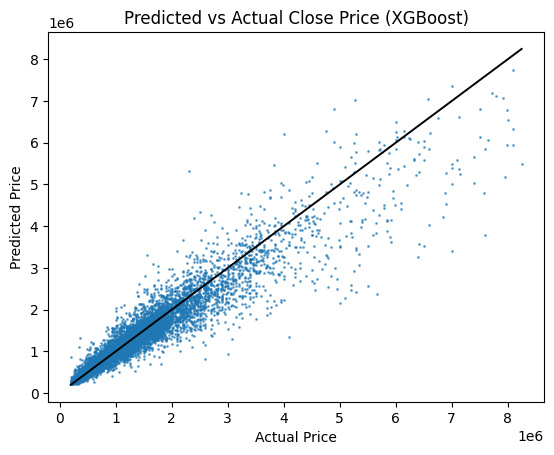

In [69]:
plt.scatter(y_test, xgb_pred_test, alpha=0.6, s=1)

limits = [min(min(y_test), min(xgb_pred_test)), max(max(y_test), max(xgb_pred_test))]
plt.plot(limits, limits, color='black', linestyle='-', linewidth=1.4)

plt.title('Predicted vs Actual Close Price (XGBoost)')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')

Text(0, 0.5, 'Predicted Price')

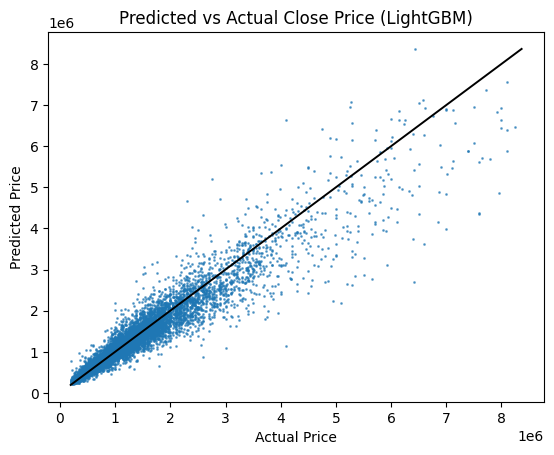

In [70]:
plt.scatter(y_test, lgb_pred_test, alpha=0.6, s=1)

limits = [min(min(y_test), min(lgb_pred_test)), max(max(y_test), max(lgb_pred_test))]
plt.plot(limits, limits, color='black', linestyle='-', linewidth=1.4)

plt.title('Predicted vs Actual Close Price (LightGBM)')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')

Divide the test data into close-price quartiles and compare predictive accuracy across quartiles.

In [ ]:
# helper function that calculates performance metrics by close-price quartile for each model
def evaluate_by_quartile(y_true, y_pred):
    results = pd.DataFrame({
        'Actual Price': y_true,
        'Predicted Price': y_pred
    })

    results['Price Quartile'] = pd.qcut(
        results['Actual Price'], 
        q=4, 
        labels=['Q1', 'Q2', 'Q3', 'Q4']
    )
    eps = 1e-8 # used to prevent division by 0 in percentage calculations

    # prioritize percentage-based metrics such as MdAPE and MAPE, as MAE and RMSE naturally increase with price
    metrics = results.groupby('Price Quartile', observed=True).apply(
        lambda x: pd.Series({
            'MdAPE': np.median(np.abs((x['Actual Price'] - x['Predicted Price']) / (x['Actual Price'] + eps)) * 100),
            'MAPE': np.mean(np.abs((x['Actual Price'] - x['Predicted Price']) / (x['Actual Price'] + eps)) * 100),
            'MAE': mean_absolute_error(x['Actual Price'], x['Predicted Price']),
            'RMSE': root_mean_squared_error(x['Actual Price'], x['Predicted Price']),
            'R²': r2_score(x['Actual Price'], x['Predicted Price'])
        })
    )
    return metrics

In [ ]:
# best MdAPE in Q2
# NOTE: Q2 and Q3 yielded negative R2, suggesting worse performance than a base model predicting overall mean
xgb_quartile_performance = evaluate_by_quartile(y_test, xgb_pred_test)
print(xgb_quartile_performance)

                    MdAPE       MAPE            MAE           RMSE        R²
Price Quartile                                                              
Q1               6.590214  11.383205   50984.703806   84090.097712  0.339949
Q2               5.865914   8.567609   66735.711378   97223.663019 -0.446693
Q3               8.136506  11.253973  130634.039737  183909.900673 -0.408090
Q4              10.965176  14.098427  365665.858243  558608.641165  0.748329


/var/folders/t2/p9112v_n469068__fty8_3nc0000gn/T/ipykernel_37709/656523770.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  metrics = results.groupby('Price Quartile', observed=True).apply(


In [ ]:
# best MdAPE in Q1
# NOTE: Q2 and Q3 yielded negative R2, suggesting worse performance than a base model predicting overall mean
lgb_quartile_performance = evaluate_by_quartile(y_test, lgb_pred_test)
print(lgb_quartile_performance)

                    MdAPE       MAPE            MAE           RMSE        R²
Price Quartile                                                              
Q1               6.749669  11.034434   49470.124632   76839.322443  0.448869
Q2               6.276777   8.564588   66648.358389   93416.604809 -0.335613
Q3               8.314727  11.087466  128974.173938  179055.717861 -0.334740
Q4              10.675997  13.635218  354399.055369  540004.560307  0.764813


/var/folders/t2/p9112v_n469068__fty8_3nc0000gn/T/ipykernel_37709/656523770.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  metrics = results.groupby('Price Quartile', observed=True).apply(
